# My favourite colour
**Colour Purple**
*Purple is my favourite colour*

## Importing the Required Libraries
The required Python libraries are imported to help with data analysis and visualization. Pandas is used for working with and analyzing the Titanic dataset, NumPy is used for numerical operations, and Matplotlib is used to create graphs and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Titanic Dataset
The Titanic dataset is loaded from a CSV file using the Pandas `read_csv()` function. The data is stored in a DataFrame called `df_titanic`, which will be used for the analysis.

# Installing libraries

In [2]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
df_titanic=pd.read_csv('titanic.csv')

## Viewing the Dataset
The first five rows of the Titanic dataset are displayed using the `head()` function. This gives an initial view of the data and helps us understand the information contained in each column.

In [4]:
df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Checking the Dataset Information¶
The info() function is used to examine the structure of the Titanic dataset. It shows the number of rows and columns, the column names, the number of non-null values, and the data type of each column. This helps identify missing data and understand the structure of the dataset before performing further analysis.

In [5]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


In [6]:
df_titanic[df_titanic['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
1299,1300,1,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
1301,1302,1,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
1304,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1307,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Set embarked to 'S' for the passange who's name contains 'Peduzzi, Mr. Josepha'


In [7]:
mask = df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', case=False, na=False)
df_titanic.loc[mask, 'Age'] = 24

In [8]:
df_titanic[df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', case=False, na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
454,455,0,3,"Peduzzi, Mr. Joseph",male,24.0,0,0,A/5 2817,8.05,NaN,S


In [9]:
mask_stone = df_titanic ['Name'].str.contains('Icard, Miss. Amelie',na=False)
df_titanic.loc[mask,'Embarked'] = 'S'

# Name -> Age lookup from the clean dataframe




In [10]:
age_lookup = (df_titanic.dropna(subset=['Age']).groupby('Name')['Age'].first().to_dict())

# Fill only the missing ages in df,matched by name

In [11]:
df_titanic['Age']=df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

In [12]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1047 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


# Fill only the missing ages in df,matched by name

In [13]:
df_titanic['Age']=df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

## Preparing the Features
The `Cabin` and `Survived` columns are removed from the dataset to create the feature dataset `X`. The `Survived` column is removed because it represents the target variable, while `Cabin` contains a large number of missing values and is not being used in this analysis.

In [14]:
X = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'],axis=1)

## Creating the Target Variable
The `Survived` column is selected as the target variable `Y`. It indicates whether each passenger survived the Titanic disaster, where `1` represents a passenger who survived and `0` represents a passenger who did not survive.

In [15]:
Y=df_titanic['Survived']

## Viewing the Feature Data
The first five rows of the feature dataset `X` are displayed to confirm that the `Cabin` and `Survived` columns have been removed successfully. The remaining columns will be used as input features for the analysis.

In [16]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Viewing the Target Data
The first five values of the target variable `Y` are displayed to confirm that the `Survived` column has been correctly selected.

In [17]:
Y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Handling Missing Values
Missing values in the `Age`, `Fare`, and `Embarked` columns are handled to prepare the dataset for further analysis.
Missing ages are replaced with the median age, while the missing fare value is replaced with the median fare. Missing values in the `Embarked` column are replaced with the most common port of embarkation, known as the mode.

In [18]:
X['Age'] = X['Age'].fillna(X['Age'].median())

# Fill the missing single fare with the median fare
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# Fill the missing embarked with the most common port (mode)
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])


## Distribution of the Target Variable
The distribution of the target variable `Survived` is visualized using a bar chart. This shows the number of passengers who survived compared with those who did not survive.
This visualization helps us understand whether the target classes are balanced or whether one class contains considerably more passengers than the other.

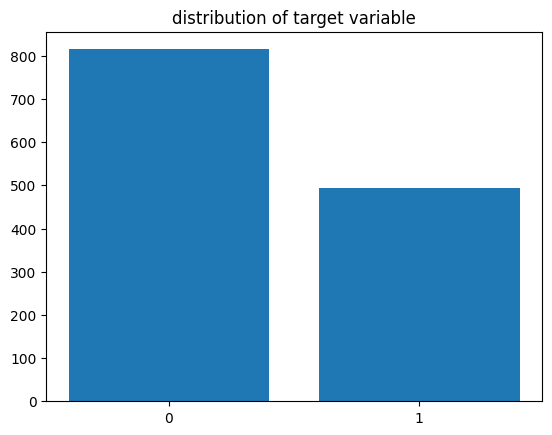

In [19]:
x_plot=Y.value_counts()
plt.bar(x_plot.index,x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target variable')
plt.show ()

## Importing Matplotlib
Matplotlib is imported to support data visualization. It will be used to create graphs and charts that help us understand patterns and relationships in the Titanic dataset.

In [20]:
import matplotlib.pyplot as plt


## Encoding Categorical Data
The `LabelEncoder` from Scikit-learn is imported to convert categorical values into numerical values. This is necessary because machine learning models generally require numerical data as input.

In [21]:
from sklearn.preprocessing import LabelEncoder

## Preparing the Data for Machine Learning
The feature dataset `X` is converted into a new DataFrame called `train`. Categorical columns containing text values are transformed into numerical values using `LabelEncoder`, while numerical columns are kept unchanged.
This prepares the feature data in a numerical format that can be used by machine learning algorithms.

In [22]:
train = pd.DataFrame()
label = LabelEncoder()
for c in X.columns:
    if X[c].dtype == 'object':
        train[c] = label.fit_transform(X[c])
    else:
        train[c] = X[c]

## Viewing the Prepared Data
The first five rows of the prepared dataset are displayed to verify that the categorical variables have been successfully converted into numerical values while the numerical variables remain unchanged.

In [23]:
train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


## Checking the Target Variable
The first five values of the target variable `Y` are displayed again to confirm that the survival values are correctly stored as the target variable for the machine learning model.

In [24]:
Y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Importing Machine Learning Tools
The required Scikit-learn tools are imported to build and evaluate the machine learning model. `train_test_split` is used to divide the data into training and testing sets, `LogisticRegression` is used to create the classification model, and `accuracy_score` is used to measure the model's performance.
`KFold` is also imported to support cross-validation of the model.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

# Importing Label Encoder Library


In [26]:
from sklearn.preprocessing import LabelEncoder

# Apllication of label encoding
This cell finds every text column/object data type in our X features and applies Label Encoding to convert it into numbers.

In [ ]:
train = pd.DataFrame()
label = LabelEncoder()

for c in X.columns:         
    if X[c].dtype == 'object':
        train[c] = label.fit_transform(X[c])
    else:
        train[c] = X[c]v

# Final check
This cell finds any remaining missing values in our train dataset and replaces them with the average value of their respective columns, ensuring the model won't crash during training.

In [28]:
train = train.fillna(train.mean())

## Training and Evaluating the Logistic Regression Model
The Logistic Regression model is trained using the prepared Titanic features and the survival variable. The dataset is divided into training and testing sets, with 80% of the data used for training and 20% used for testing.
The model is fitted using the training data and then used to predict the survival outcomes of the passengers in the testing set. The predictions are compared with the actual survival values using accuracy score to determine how well the model performs.

In [29]:
def logistic(X, y):
    X_clean = X.drop(columns=['PassengerId', 'Name', 'Ticket'], errors='ignore')
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y, random_state=42, test_size=0.2)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    print('Accuracy : ', accuracy_score(y_test, y_pred))

## Evaluating the Model
The Logistic Regression function is called using the prepared feature dataset `train` and the target variable `Y`. The model's accuracy is then calculated to determine how accurately it predicts whether passengers survived the Titanic disaster.

## Model Accuracy Result
The Logistic Regression model achieved an accuracy of approximately **85.11%** on the testing data. This means that the model correctly predicted the survival outcome for about 85% of the passengers in the test set.
The result indicates that Logistic Regression provides a reasonably strong prediction of passenger survival using the selected features.

In [30]:
logistic(train,Y)

Accuracy :  0.851145038167939


# Method 2: On Hot Encoding
## One-Hot Encoding with pd.get_dummies()
We use pandas get_dummies() to convert categorical columns (Sex, Embarked) into binary columns.

In [31]:
X_encoded = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

## Any Remaining columns
This cell finds any remaining missing values in our train dataset and replaces them with the average value of their respective columns, ensuring the model won't crash during training.

In [32]:
X_encoded = X_encoded.fillna(X_encoded.mean())

## Convertion
This cell converts to integers for cleaner output

In [33]:
X_encoded = X_encoded.astype(np.int8)


## Previewing X_encoded
This cell gives you the first five rows in the x_encoded file

In [34]:
X_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22,1,0,7,1,0,1
1,1,38,1,0,71,0,0,0
2,3,26,0,0,7,0,0,1
3,1,35,1,0,53,0,0,1
4,3,35,0,0,8,1,0,1


## Training the Logistic Regression Model
This cell splits the encoded data into training and testing sets, then train and evaluate the model.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, random_state=42, test_size=0.2)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)

Y_pred = lr.predict(X_test)

print('Accuracy:', accuracy_score(Y_test, Y_pred))

Accuracy: 0.8473282442748091
